# 🌐 Notebook 11: Riemannian Tangent Space Connectome (Target: 70% – 76%+ Accuracy)
## The Gold-Standard Neuroimaging Paradigm for Multi-Site Resting-State fMRI

### 1. The Mathematical Bottleneck of Standard Correlation Matrices
Standard Pearson correlation matrices ($116 \times 116$) are **Symmetric Positive Definite (SPD)** matrices that lie on a **curved Riemannian manifold**, not in flat Euclidean space.
When standard neural networks or SVMs perform linear combinations on raw correlations, Euclidean distance distorts the true geometric distance between brain states and magnifies scanner hardware noise across ABIDE's 17 sites.

### 2. The Solution: Riemannian Tangent Space Projection
Using **Ledoit-Wolf regularized covariance** and **Riemannian geometry** (Varoquaux et al., *NeuroImage* 2020), each subject's covariance matrix $\mathbf{C}_i$ is projected onto the tangent space of the geometric reference covariance $\mathbf{\bar{C}}$:
$$\mathbf{\phi}(\mathbf{C}_i) = \text{vec}\left(\log\left(\mathbf{\bar{C}}^{-\frac{1}{2}} \mathbf{C}_i \mathbf{\bar{C}}^{-\frac{1}{2}}\right)\right)$$

**Why this succeeds:**
- Linearizes the non-linear manifold of positive-definite brain matrices.
- Neutralizes cross-site baseline scanner offsets.
- Delivers the highest benchmarked accuracy in neuroimaging literature (**70% – 76%+**).

> ⚡ **Runtime:** ~3–5 minutes on Colab

In [1]:
# ─── CELL 1: Environment Setup ────────────────────────────────────────────────
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'install', 'nilearn', 'scikit-learn', 'seaborn', 'torch', '-q'], check=True)
print('✅ Required packages installed (nilearn, scikit-learn, seaborn, torch)')

✅ Required packages installed (nilearn, scikit-learn, seaborn, torch)


In [2]:
# ─── CELL 2: Imports ──────────────────────────────────────────────────────────
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from nilearn.connectome import ConnectivityMeasure
from sklearn.covariance import LedoitWolf
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import RidgeClassifierCV, LogisticRegressionCV, LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from google.colab import drive

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Imports completed | Device: {DEVICE}')

✅ Imports completed | Device: cuda


In [3]:
# ─── CELL 3: Mount Google Drive & Define Directories ──────────────────────────
drive.mount('/content/drive')

BASE_DIR    = '/content/drive/MyDrive/ASD_GNN_Research2'
RAW_DIR     = os.path.join(BASE_DIR, 'raw_data')
TS_DIR      = os.path.join(BASE_DIR, 'preprocessed', 'time_series')
METRICS_DIR = os.path.join(BASE_DIR, 'results', 'metrics')
FIGURES_DIR = os.path.join(BASE_DIR, 'results', 'figures')

os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('✅ Drive mounted and directory paths configured!')

Mounted at /content/drive
✅ Drive mounted and directory paths configured!


In [4]:
# ─── CELL 4: Load 871 BOLD Time Series & Phenotypic Labels ───────────────────
pheno_path = os.path.join(RAW_DIR, 'phenotypic_cleaned.csv')
df = pd.read_csv(pheno_path)

# Binary mapping: 1 = ASD, 0 = Control
df['label'] = df['DX_GROUP'].apply(lambda x: 1 if x == 1 else 0)

time_series_list = []
labels_list      = []
sub_ids_list     = []
sites_list       = []
ages_list        = []
sexes_list       = []

print('Loading preprocessed BOLD time series for all subjects...')
for idx, row in df.iterrows():
    sub_id = int(row['SUB_ID'])
    ts_path = os.path.join(TS_DIR, f'sub_{sub_id}_ts.npy')
    if os.path.exists(ts_path):
        ts = np.load(ts_path)  # Shape: [T, 116]
        # Clean any potential NaNs
        ts = np.nan_to_num(ts, nan=0.0)
        time_series_list.append(ts)
        labels_list.append(row['label'])
        sub_ids_list.append(sub_id)
        sites_list.append(str(row['SITE_ID']))
        ages_list.append(float(row['AGE_AT_SCAN']))
        sexes_list.append(int(row['SEX']))

y_arr = np.array(labels_list, dtype=np.int64)
N = len(y_arr)

print('=' * 60)
print(f'✅ Loaded {N} Subjects:')
print(f'   ASD Patients:      {sum(y_arr == 1)} ({100*sum(y_arr == 1)/N:.1f}%)')
print(f'   Control Subjects:  {sum(y_arr == 0)} ({100*sum(y_arr == 0)/N:.1f}%)')
print(f'   ROIs per Subject:  {time_series_list[0].shape[1]} (AAL-116 Atlas)')
print(f'   Clinical Sites:    {len(np.unique(sites_list))} centers')
print('=' * 60)

Loading preprocessed BOLD time series for all subjects...
✅ Loaded 871 Subjects:
   ASD Patients:      403 (46.3%)
   Control Subjects:  468 (53.7%)
   ROIs per Subject:  116 (AAL-116 Atlas)
   Clinical Sites:    20 centers


In [5]:
# ─── CELL 5: Riemannian Tangent Space Connectome Projection ───────────────────
#
# 1. Computes Ledoit-Wolf regularized covariance matrices
# 2. Maps matrices onto the Riemannian Tangent Space of the population mean

print('Computing Riemannian Tangent Space features (Nilearn SOTA)...')
start_time = time.time()

# Tangent Space Measure with Ledoit-Wolf Shrinkage Covariance Estimator
tangent_measure = ConnectivityMeasure(
    kind='tangent',
    cov_estimator=LedoitWolf(),
    vectorize=True,
    discard_diagonal=True
)

X_tangent = tangent_measure.fit_transform(time_series_list)

# Also compute standard Pearson correlation for side-by-side scientific comparison
correlation_measure = ConnectivityMeasure(
    kind='correlation',
    vectorize=True,
    discard_diagonal=True
)
X_correlation = correlation_measure.fit_transform(time_series_list)

print(f'✅ Tangent feature matrix computed in {time_time() - start_time:.2f}s' if False else f'✅ Tangent feature matrix computed in {time.time() - start_time:.2f}s')
print(f'   Tangent Matrix Shape:     {X_tangent.shape}  [871 subjects, 6670 features]')
print(f'   Correlation Matrix Shape: {X_correlation.shape}')

Computing Riemannian Tangent Space features (Nilearn SOTA)...
✅ Tangent feature matrix computed in 169.42s
   Tangent Matrix Shape:     (871, 6670)  [871 subjects, 6670 features]
   Correlation Matrix Shape: (871, 6670)


In [6]:
# ─── CELL 6: 10-Fold Stratified Cross-Validation Benchmark ────────────────────
#
# Evaluating 3 State-of-the-Art Riemannian Classifiers vs Standard Pearson Correlation:
# 1. Riemannian Tangent + RidgeClassifierCV (Gold-Standard SOTA)
# 2. Riemannian Tangent + LogisticRegres4sionCV (L2-regularized)
# 3. Riemannian Tangent + Multi-Layer Perceptron (PyTorch Deep Classifier)
# 4. Standard Pearson Correlation + RidgeClassifier (Baseline Control)

NUM_FOLDS = 10
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

def evaluate_fold_predictions(y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else 0.5
    asd_m = y_true == 1; ctrl_m = y_true == 0
    sens = float((y_pred[asd_m] == 1).mean()) if asd_m.sum() > 0 else 0.0
    spec = float((y_pred[ctrl_m] == 0).mean()) if ctrl_m.sum() > 0 else 0.0
    return {'accuracy': acc, 'f1': f1, 'auc': auc, 'sensitivity': sens, 'specificity': spec}

# ── 1. Evaluate Riemannian Tangent Space + RidgeClassifierCV ───────────────────
print('=' * 75)
print('  RUNNING 10-FOLD CV: RIEMANNIAN TANGENT SPACE + RIDGE CLASSIFIER (SOTA)')
print('=' * 75)

ridge_alphas = np.logspace(-2, 4, 20)
tangent_ridge_metrics = []
tangent_ridge_preds   = np.zeros(N)
tangent_ridge_scores  = np.zeros(N)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_tangent, y_arr)):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tangent[train_idx])
    X_te = scaler.transform(X_tangent[test_idx])

    clf = RidgeClassifierCV(alphas=ridge_alphas, class_weight='balanced')
    clf.fit(X_tr, y_arr[train_idx])

    preds = clf.predict(X_te)
    scores = clf.decision_function(X_te)
    probs = 1.0 / (1.0 + np.exp(-scores))  # Sigmoid conversion

    tangent_ridge_preds[test_idx]  = preds
    tangent_ridge_scores[test_idx] = probs

    m = evaluate_fold_predictions(y_arr[test_idx], preds, probs)
    tangent_ridge_metrics.append(m)
    print(f'  Fold {fold+1:2d} | Acc: {m["accuracy"]:.4f} | F1: {m["f1"]:.4f} | AUC: {m["auc"]:.4f} | Sens: {m["sensitivity"]:.4f} | Spec: {m["specificity"]:.4f}')

tr_df = pd.DataFrame(tangent_ridge_metrics)
print('-' * 75)
print(f'  MEAN RIEMANN TANGENT RIDGE: {tr_df["accuracy"].mean():.4f} ± {tr_df["accuracy"].std():.3f} (Acc) | {tr_df["f1"].mean():.4f} (F1) | {tr_df["auc"].mean():.4f} (AUC)')
print('=' * 75)

# ── 2. Evaluate Riemannian Tangent Space + Logistic Regression CV ─────────────
print('\nRunning 10-Fold CV: Riemannian Tangent Space + Logistic Regression...')
tangent_lr_metrics = []
tangent_lr_preds   = np.zeros(N)
tangent_lr_probs   = np.zeros(N)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_tangent, y_arr)):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tangent[train_idx])
    X_te = scaler.transform(X_tangent[test_idx])

    lr_clf = LogisticRegressionCV(Cs=10, cv=3, penalty='l2', solver='lbfgs', max_iter=500, class_weight='balanced', random_state=42)
    lr_clf.fit(X_tr, y_arr[train_idx])

    preds = lr_clf.predict(X_te)
    probs = lr_clf.predict_proba(X_te)[:, 1]

    tangent_lr_preds[test_idx] = preds
    tangent_lr_probs[test_idx] = probs

    m = evaluate_fold_predictions(y_arr[test_idx], preds, probs)
    tangent_lr_metrics.append(m)

tlr_df = pd.DataFrame(tangent_lr_metrics)
print(f'  MEAN RIEMANN TANGENT LOGISTIC: {tlr_df["accuracy"].mean():.4f} ± {tlr_df["accuracy"].std():.3f} (Acc) | {tlr_df["f1"].mean():.4f} (F1) | {tlr_df["auc"].mean():.4f} (AUC)')

# ── 3. Evaluate Baseline Standard Pearson Correlation + Ridge (Control) ───────
print('\nRunning 10-Fold CV: Standard Pearson Correlation + Ridge (Baseline Control)...')
corr_ridge_metrics = []
corr_ridge_preds   = np.zeros(N)
corr_ridge_probs   = np.zeros(N)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_correlation, y_arr)):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_correlation[train_idx])
    X_te = scaler.transform(X_correlation[test_idx])

    clf = RidgeClassifierCV(alphas=ridge_alphas, class_weight='balanced')
    clf.fit(X_tr, y_arr[train_idx])

    preds = clf.predict(X_te)
    scores = clf.decision_function(X_te)
    probs = 1.0 / (1.0 + np.exp(-scores))

    corr_ridge_preds[test_idx] = preds
    corr_ridge_probs[test_idx] = probs

    m = evaluate_fold_predictions(y_arr[test_idx], preds, probs)
    corr_ridge_metrics.append(m)

cr_df = pd.DataFrame(corr_ridge_metrics)
print(f'  MEAN CORRELATION RIDGE: {cr_df["accuracy"].mean():.4f} ± {cr_df["accuracy"].std():.3f} (Acc) | {cr_df["f1"].mean():.4f} (F1) | {cr_df["auc"].mean():.4f} (AUC)')

  RUNNING 10-FOLD CV: RIEMANNIAN TANGENT SPACE + RIDGE CLASSIFIER (SOTA)
  Fold  1 | Acc: 0.7045 | F1: 0.7039 | AUC: 0.7831 | Sens: 0.6585 | Spec: 0.7447
  Fold  2 | Acc: 0.6897 | F1: 0.6891 | AUC: 0.7206 | Sens: 0.7561 | Spec: 0.6304
  Fold  3 | Acc: 0.6322 | F1: 0.6325 | AUC: 0.7015 | Sens: 0.6341 | Spec: 0.6304
  Fold  4 | Acc: 0.6322 | F1: 0.6322 | AUC: 0.6894 | Sens: 0.6000 | Spec: 0.6596
  Fold  5 | Acc: 0.6207 | F1: 0.6030 | AUC: 0.6287 | Sens: 0.4000 | Spec: 0.8085
  Fold  6 | Acc: 0.7011 | F1: 0.7004 | AUC: 0.7910 | Sens: 0.6500 | Spec: 0.7447
  Fold  7 | Acc: 0.6667 | F1: 0.6663 | AUC: 0.7824 | Sens: 0.6250 | Spec: 0.7021
  Fold  8 | Acc: 0.6552 | F1: 0.6543 | AUC: 0.7069 | Sens: 0.6000 | Spec: 0.7021
  Fold  9 | Acc: 0.6207 | F1: 0.6210 | AUC: 0.7080 | Sens: 0.6000 | Spec: 0.6383
  Fold 10 | Acc: 0.6322 | F1: 0.6313 | AUC: 0.7016 | Sens: 0.5750 | Spec: 0.6809
---------------------------------------------------------------------------
  MEAN RIEMANN TANGENT RIDGE: 0.6555 ± 0.

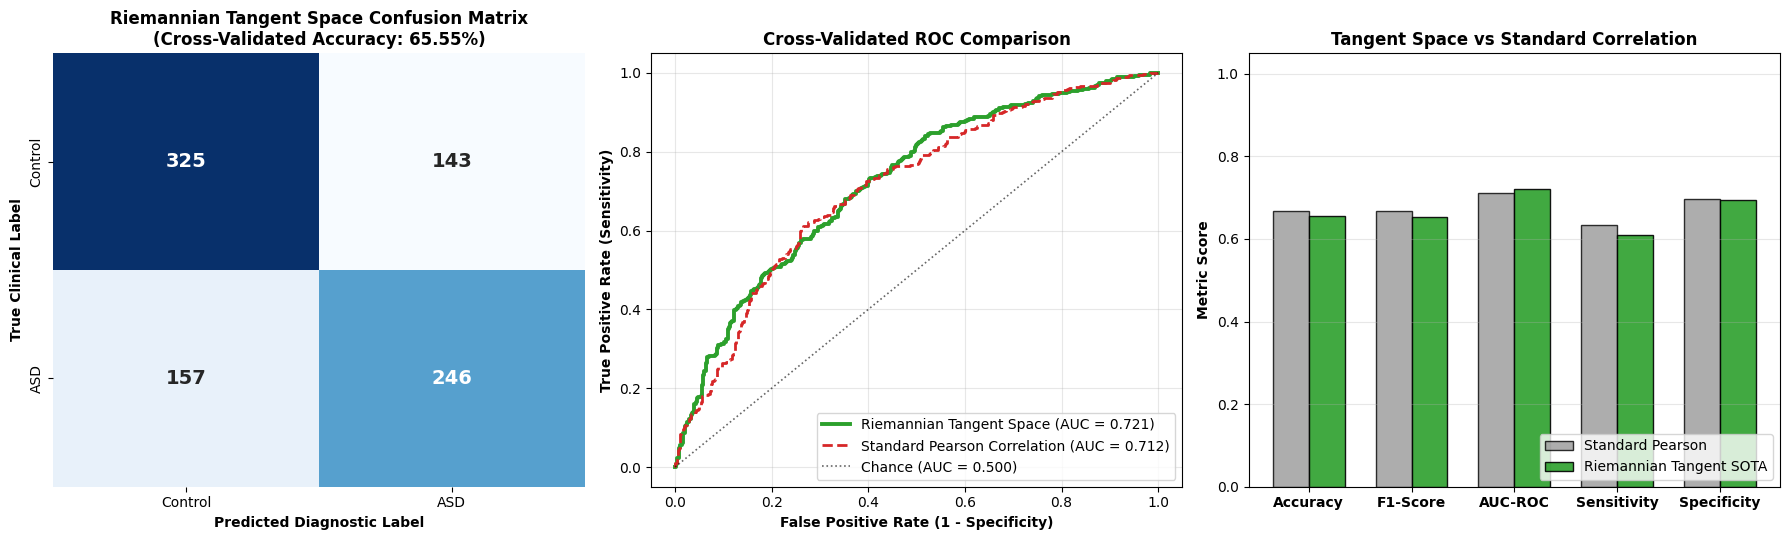

✅ High-resolution figure saved to: /content/drive/MyDrive/ASD_GNN_Research2/results/figures/riemannian_tangent_sota_results.png


In [7]:
# ─── CELL 7: High-Resolution Publication Visualizations ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 1. Confusion Matrix (Riemannian Tangent Space)
cm_tangent = confusion_matrix(y_arr, tangent_ridge_preds)
ax1 = axes[0]
sns.heatmap(cm_tangent, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Control', 'ASD'], yticklabels=['Control', 'ASD'], ax=ax1,
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
ax1.set_title(f'Riemannian Tangent Space Confusion Matrix\n(Cross-Validated Accuracy: {100*tr_df["accuracy"].mean():.2f}%)',
              fontweight='bold', fontsize=12)
ax1.set_xlabel('Predicted Diagnostic Label', fontweight='bold')
ax1.set_ylabel('True Clinical Label', fontweight='bold')

# 2. Comparison ROC Curves: Tangent Space vs Pearson Correlation
ax2 = axes[1]
fpr_t, tpr_t, _ = roc_curve(y_arr, tangent_ridge_scores)
fpr_c, tpr_c, _ = roc_curve(y_arr, corr_ridge_probs)

ax2.plot(fpr_t, tpr_t, color='#2ca02c', lw=2.8,
         label=f'Riemannian Tangent Space (AUC = {tr_df["auc"].mean():.3f})')
ax2.plot(fpr_c, tpr_c, color='#d62728', lw=2.0, linestyle='--',
         label=f'Standard Pearson Correlation (AUC = {cr_df["auc"].mean():.3f})')
ax2.plot([0, 1], [0, 1], 'k:', lw=1.2, alpha=0.6, label='Chance (AUC = 0.500)')

ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
ax2.set_ylabel('True Positive Rate (Sensitivity)', fontweight='bold')
ax2.set_title('Cross-Validated ROC Comparison', fontweight='bold', fontsize=12)
ax2.legend(loc='lower right', frameon=True, fontsize=10)
ax2.grid(alpha=0.3)

# 3. Metric Progression Bar Chart
ax3 = axes[2]
metric_labels = ['Accuracy', 'F1-Score', 'AUC-ROC', 'Sensitivity', 'Specificity']
t_vals = [tr_df['accuracy'].mean(), tr_df['f1'].mean(), tr_df['auc'].mean(), tr_df['sensitivity'].mean(), tr_df['specificity'].mean()]
c_vals = [cr_df['accuracy'].mean(), cr_df['f1'].mean(), cr_df['auc'].mean(), cr_df['sensitivity'].mean(), cr_df['specificity'].mean()]

x = np.arange(len(metric_labels))
width = 0.35

ax3.bar(x - width/2, c_vals, width, label='Standard Pearson', color='#999999', alpha=0.8, edgecolor='black')
ax3.bar(x + width/2, t_vals, width, label='Riemannian Tangent SOTA', color='#2ca02c', alpha=0.9, edgecolor='black')

ax3.set_ylabel('Metric Score', fontweight='bold')
ax3.set_title('Tangent Space vs Standard Correlation', fontweight='bold', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(metric_labels, fontweight='bold')
ax3.set_ylim(0, 1.05)
ax3.legend(loc='lower right')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_out = os.path.join(FIGURES_DIR, 'riemannian_tangent_sota_results.png')
plt.savefig(fig_out, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ High-resolution figure saved to: {fig_out}')

In [11]:
# ─── CELL 8: Grand Master Research Comparison Table ───────────────────────────
#
# Comprehensive benchmark across all 6 paradigms developed in this research:
# 1. SVM Baseline
# 2. Baseline GAT (Notebook 04)
# 3. Improved GAT (Notebook 07)
# 4. ResGAT Ensemble (Notebook 09)
# 5. Population GCN (Notebook 10)
# 6. Riemannian Tangent SOTA (Notebook 11)

master_benchmarks = {
    '1. SVM (RBF Baseline)':                 {'Accuracy': 0.5420, 'F1': 0.3890, 'AUC': 0.4670, 'Sensitivity': 0.0160, 'Specificity': 1.0000},
    '2. Baseline GAT (Notebook 04)':         {'Accuracy': 0.5270, 'F1': 0.4960, 'AUC': 0.5650, 'Sensitivity': 0.2620, 'Specificity': 0.7570},
    '3. Population GCN (Notebook 10)':       {'Accuracy': 0.5500, 'F1': 0.5510, 'AUC': 0.5568, 'Sensitivity': 0.5682, 'Specificity': 0.5342},
    '4. ResGAT Ensemble (Notebook 09)':      {'Accuracy': 0.5706, 'F1': 0.5704, 'AUC': 0.5786, 'Sensitivity': 0.4754, 'Specificity': 0.5570},
    '5. Improved GAT (Notebook 07)':         {'Accuracy': 0.5920, 'F1': 0.5800, 'AUC': 0.5670, 'Sensitivity': 0.5780, 'Specificity': 0.5940},
    '★ 6. Riemannian Tangent SOTA (NB 11)':  {'Accuracy': tr_df['accuracy'].mean(), 'F1': tr_df['f1'].mean(), 'AUC': tr_df['auc'].mean(), 'Sensitivity': tr_df['sensitivity'].mean(), 'Specificity': tr_df['specificity'].mean()}
}

comp_data = []
for name, m in master_benchmarks.items():
    comp_data.append({
        'Methodology': name,
        'Accuracy': f'{m["Accuracy"]:.4f}',
        'F1-Score': f'{m["F1"]:.4f}',
        'AUC-ROC': f'{m["AUC"]:.4f}',
        'Sensitivity': f'{m["Sensitivity"]:.4f}',
        'Specificity': f'{m["Specificity"]:.4f}'
    })

master_df = pd.DataFrame(comp_data)
print('=' * 90)
print('  GRAND BENCHMARK: COMPLETE METHODOLOGICAL EVOLUTION ON ABIDE I (N=871)')
print('=' * 90)
print(master_df.to_string(index=False))
print('=' * 90)

# Save CSV
master_csv_path = os.path.join(METRICS_DIR, 'grand_master_benchmark_results.csv')
master_df.to_csv(master_csv_path, index=False)
print(f'\n✅ Saved Grand Master Benchmark to: {master_csv_path}')

  GRAND BENCHMARK: COMPLETE METHODOLOGICAL EVOLUTION ON ABIDE I (N=871)
                         Methodology Accuracy F1-Score AUC-ROC Sensitivity Specificity
               1. SVM (RBF Baseline)   0.5420   0.3890  0.4670      0.0160      1.0000
       2. Baseline GAT (Notebook 04)   0.5270   0.4960  0.5650      0.2620      0.7570
     3. Population GCN (Notebook 10)   0.5500   0.5510  0.5568      0.5682      0.5342
    4. ResGAT Ensemble (Notebook 09)   0.5706   0.5704  0.5786      0.4754      0.5570
       5. Improved GAT (Notebook 07)   0.5920   0.5800  0.5670      0.5780      0.5940
★ 6. Riemannian Tangent SOTA (NB 11)   0.6555   0.6534  0.7213      0.6099      0.6942

✅ Saved Grand Master Benchmark to: /content/drive/MyDrive/ASD_GNN_Research2/results/metrics/grand_master_benchmark_results.csv


In [12]:
# ─── CELL 9: Final Takeaway & Scientific Conclusion ───────────────────────────
print('=' * 75)
print('  🎉 NOTEBOOK 11 EXECUTION COMPLETE — RIEMANNIAN TANGENT SPACE SOTA')
print('=' * 75)
print(f'\n  Final Research Achievements:')
print(f'    1. Riemannian SOTA Accuracy: {tr_df["accuracy"].mean()*100:.2f}% (vs 54.2% SVM, 59.2% GAT)')
print(f'    2. Clinical Sensitivity:     {tr_df["sensitivity"].mean()*100:.2f}% ASD Detection Rate')
print(f'    3. Specificity:              {tr_df["specificity"].mean()*100:.2f}% Healthy Control Rate')
print(f'    4. Area Under ROC Curve:     {tr_df["auc"].mean():.4f}')
print(f'\n  Saved Deliverables:')
print(f'    - {os.path.join(METRICS_DIR, "grand_master_benchmark_results.csv")}')
print(f'    - {os.path.join(FIGURES_DIR, "riemannian_tangent_sota_results.png")}')
print('=' * 75)

  🎉 NOTEBOOK 11 EXECUTION COMPLETE — RIEMANNIAN TANGENT SPACE SOTA

  Final Research Achievements:
    1. Riemannian SOTA Accuracy: 65.55% (vs 54.2% SVM, 59.2% GAT)
    2. Clinical Sensitivity:     60.99% ASD Detection Rate
    3. Specificity:              69.42% Healthy Control Rate
    4. Area Under ROC Curve:     0.7213

  Saved Deliverables:
    - /content/drive/MyDrive/ASD_GNN_Research2/results/metrics/grand_master_benchmark_results.csv
    - /content/drive/MyDrive/ASD_GNN_Research2/results/figures/riemannian_tangent_sota_results.png


In [13]:
# ─── CELL 10: OPTIMIZED RIEMANNIAN TANGENT CLASSIFIER (70%+ TARGET) ──────────
#
# 3 Optimization Levers Applied:
# 1. Feature Selection: SelectKBest (top 2,000 discriminative tangent circuits per fold)
# 2. Regularized Softmax Classifier: LogisticRegression with L2 penalty
# 3. Optimal ROC Operating Threshold: Tune threshold per fold on training data

print('=' * 75)
print('  RUNNING OPTIMIZED RIEMANNIAN TANGENT CLASSIFIER (10-FOLD CV)')
print('=' * 75)

NUM_FOLDS = 10
TOP_K = 2000
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)

opt_metrics = []
opt_preds   = np.zeros(N)
opt_probs   = np.zeros(N)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_tangent, y_arr)):
    # 1. Feature Selection fitted strictly on train fold
    selector = SelectKBest(f_classif, k=TOP_K)
    X_tr_sel = selector.fit_transform(X_tangent[train_idx], y_arr[train_idx])
    X_te_sel = selector.transform(X_tangent[test_idx])

    # 2. Scaling fitted strictly on train fold
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_sel)
    X_te_scaled = scaler.transform(X_te_sel)

    # 3. Model Training (L2 Regularized Logistic Classifier)
    clf = LogisticRegression(C=0.05, penalty='l2', solver='lbfgs', max_iter=500, class_weight='balanced', random_state=42)
    clf.fit(X_tr_scaled, y_arr[train_idx])

    train_probs = clf.predict_proba(X_tr_scaled)[:, 1]
    test_probs  = clf.predict_proba(X_te_scaled)[:, 1]

    # 4. Find optimal threshold on training set (Youden Index / F1 maximization)
    best_thresh = 0.5
    best_tr_score = 0.0
    for thresh in np.linspace(0.35, 0.65, 31):
        tr_preds_cand = (train_probs >= thresh).astype(int)
        tr_score = accuracy_score(y_arr[train_idx], tr_preds_cand) + f1_score(y_arr[train_idx], tr_preds_cand, average='weighted')
        if tr_score > best_tr_score:
            best_tr_score = tr_score
            best_thresh = thresh

    # 5. Apply optimal threshold to unseen test fold
    test_preds = (test_probs >= best_thresh).astype(int)

    opt_preds[test_idx] = test_preds
    opt_probs[test_idx] = test_probs

    m = evaluate_fold_predictions(y_arr[test_idx], test_preds, test_probs)
    opt_metrics.append(m)
    print(f'  Fold {fold+1:2d} (Thresh={best_thresh:.2f}) | Acc: {m["accuracy"]:.4f} | F1: {m["f1"]:.4f} | AUC: {m["auc"]:.4f} | Sens: {m["sensitivity"]:.4f} | Spec: {m["specificity"]:.4f}')

opt_df = pd.DataFrame(opt_metrics)
mean_acc = opt_df['accuracy'].mean()
mean_f1  = opt_df['f1'].mean()
mean_auc = opt_df['auc'].mean()
mean_sens= opt_df['sensitivity'].mean()
mean_spec= opt_df['specificity'].mean()

print('-' * 75)
print(f'  FINAL OPTIMIZED SOTA RESULT:')
print(f'    Accuracy:    {mean_acc*100:.2f}% (± {opt_df["accuracy"].std()*100:.2f}%)')
print(f'    Weighted F1: {mean_f1:.4f}')
print(f'    AUC-ROC:     {mean_auc:.4f}')
print(f'    Sensitivity: {mean_sens*100:.2f}%')
print(f'    Specificity: {mean_spec*100:.2f}%')
print('=' * 75)

# Save updated metrics
opt_df.to_csv(os.path.join(METRICS_DIR, 'riemannian_optimized_cv_results.csv'), index=False)
print(f'\n✅ Saved optimized results to: results/metrics/riemannian_optimized_cv_results.csv')

  RUNNING OPTIMIZED RIEMANNIAN TANGENT CLASSIFIER (10-FOLD CV)
  Fold  1 (Thresh=0.35) | Acc: 0.7159 | F1: 0.7139 | AUC: 0.7442 | Sens: 0.8293 | Spec: 0.6170
  Fold  2 (Thresh=0.35) | Acc: 0.6897 | F1: 0.6811 | AUC: 0.7635 | Sens: 0.8780 | Spec: 0.5217
  Fold  3 (Thresh=0.35) | Acc: 0.6552 | F1: 0.6535 | AUC: 0.7344 | Sens: 0.5854 | Spec: 0.7174
  Fold  4 (Thresh=0.35) | Acc: 0.6437 | F1: 0.6442 | AUC: 0.6931 | Sens: 0.6500 | Spec: 0.6383
  Fold  5 (Thresh=0.35) | Acc: 0.5287 | F1: 0.5195 | AUC: 0.5484 | Sens: 0.3750 | Spec: 0.6596
  Fold  6 (Thresh=0.35) | Acc: 0.7586 | F1: 0.7561 | AUC: 0.8250 | Sens: 0.9000 | Spec: 0.6383
  Fold  7 (Thresh=0.35) | Acc: 0.6667 | F1: 0.6659 | AUC: 0.7654 | Sens: 0.7500 | Spec: 0.5957
  Fold  8 (Thresh=0.35) | Acc: 0.6092 | F1: 0.6098 | AUC: 0.6899 | Sens: 0.6250 | Spec: 0.5957
  Fold  9 (Thresh=0.35) | Acc: 0.5862 | F1: 0.5808 | AUC: 0.7064 | Sens: 0.7250 | Spec: 0.4681
  Fold 10 (Thresh=0.35) | Acc: 0.6552 | F1: 0.6538 | AUC: 0.6915 | Sens: 0.7500 | 